<a href="https://colab.research.google.com/github/abeeraz379/Prediction-of-Product-sales/blob/main/prediction%20of%20product%20sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction for product sales
 - ABeer Al-Zebda | Data Scientist


# Project Overview

**This project analyzes a Product Sales dataset by first inspecting and cleaning the data to prepare it for visualization. We then perform exploratory data analysis (EDA) to identify correlations, create plots to uncover patterns, and derive key insights. The primary goal is to build a predictive model for Product Sales and use the findings to inform strategies for increasing property values.**

**Data Link:** https://www.analyticsvidhya.com/datahack/contest/practice-problem-big-mart-sales-iii/

#Load and inspect data

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
path='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df= pd.read_csv(path)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
# to know more about data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Data Set info
- number of column :12
- number of rows :8522

 ## Types of Columns
- 7 Categorical Columns
- 1 int Column
- 4 float Columns   

#Clean Data

## Check for duplicates

In [5]:
df.duplicated(keep=False).sum()

np.int64(0)

## Check for Missing Values

In [6]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


## Missing Values Rate

In [7]:
df.isna().sum()/len(df)*100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


## Handling Missing Value

In [8]:
# using describe to see the statstical info for Item_Weight
df['Item_Weight'].describe()

,Item_Weight
count,7060.000000
mean,12.857645
std,4.643456
min,4.555000
25%,8.773750
50%,12.600000
75%,16.850000
max,21.350000


In [9]:
df['Item_Weight'].value_counts()

,count
Item_Weight,
12.150,86
17.600,82
13.650,77
11.800,76
15.100,68
...,...
8.920,2
6.520,1
9.420,1


In [10]:
# fill the missing value with placeholder = -1
df['Item_Weight']=df['Item_Weight'].fillna(-1 )
df['Item_Weight'].isna().sum()

np.int64(0)

In [11]:
# search for the most frequency value
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


In [12]:
# handle the missing value with Placeholder Missing
df['Outlet_Size']=df['Outlet_Size'].fillna('Missing')
df['Outlet_Size'].isna().sum()


np.int64(0)

In [13]:
# check that there is no missing value anymore
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


<Axes: >

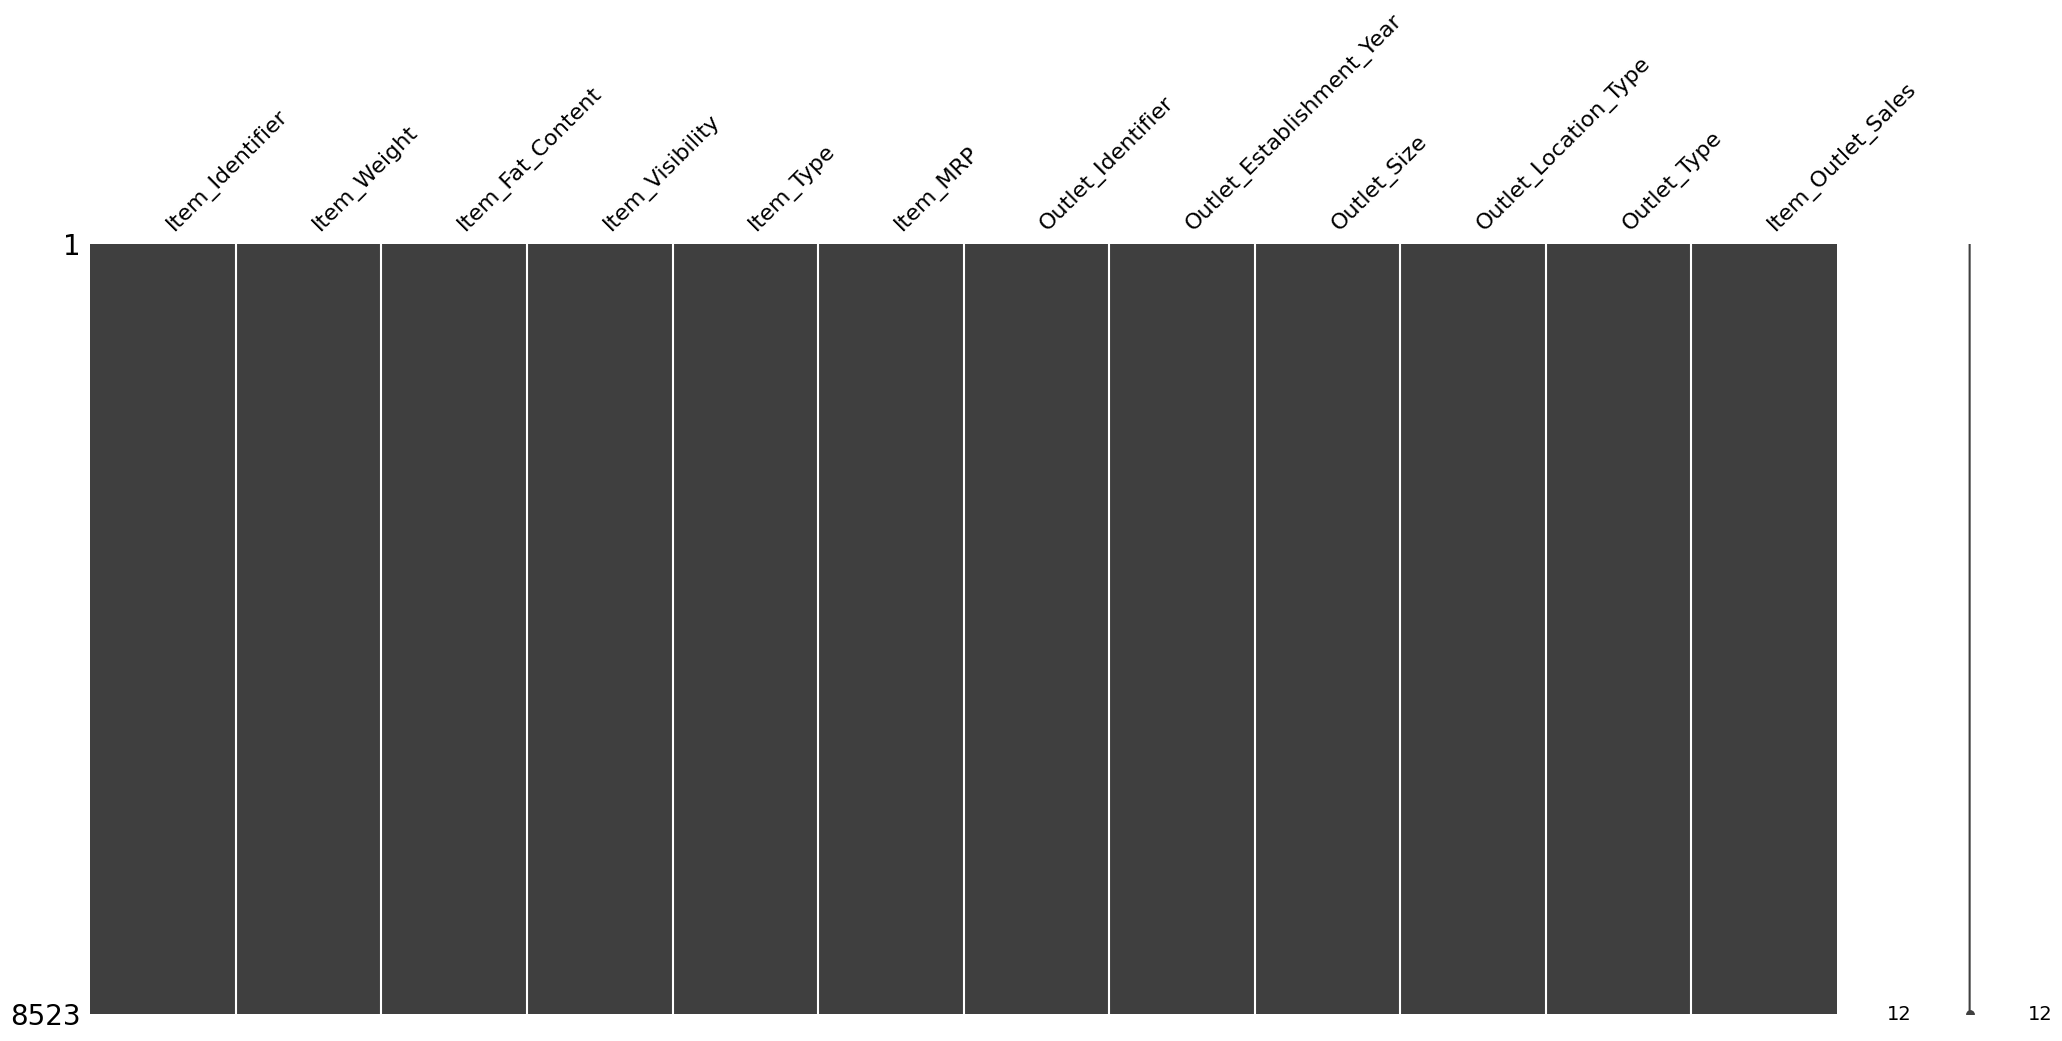

In [14]:
import missingno as msno
msno.matrix(df)

## Check Consistancy

In [15]:
# see the values for each column with it frequency to check the consistancy
for col in df.columns:
  print( df[col].value_counts())
  print('\n')

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64


Item_Weight
-1.000     1463
 12.150      86
 17.600      82
 13.650      77
 11.800      76
           ... 
 5.210        2
 9.420        1
 7.685        1
 5.400        1
 6.520        1
Name: count, Length: 416, dtype: int64


Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


Item_Visibility
0.000000    526
0.076975      3
0.061271      2
0.046825      2
0.112399      2
           ... 
0.054142      1
0.018920      1
0.044974      1
0.103611      1
0.083060      1
Name: count, Length: 7880, dtype: int64


Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
He

## Handling inconstancy

In [16]:
# replace the inconstancy values with the right values
df['Item_Fat_Content']= df['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

In [17]:
# check to make sure that data now is clean
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


## Save the clean data

In [18]:
# save the clean data into new file called cleaning product sales using to_csv
fpath='/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week03/Data/Cleaning_ProductSales.csv'
new_df=df.to_csv(fpath,index=False)


In [19]:
new_df=pd.read_csv(fpath)
new_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Missing,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#Exploratory Data Analysis

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Histogram Plot

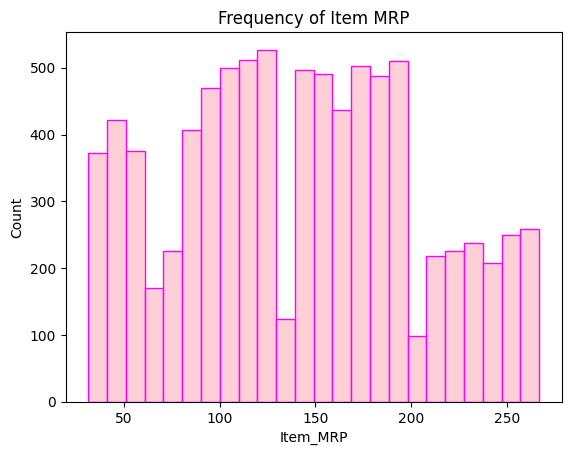

In [21]:
# make histogram for Item MRP
ax =sns.histplot(data=new_df, x='Item_MRP',binwidth=10,color='Pink',edgecolor='#FF00FF')
ax.ticklabel_format(style='plain', axis='x')
ax.set_title('Frequency of Item MRP');

## Box Plot

In [22]:
# To know more info about Outlet_Establishment_Year column using describe
df['Outlet_Establishment_Year'].describe()

,Outlet_Establishment_Year
count,8523.000000
mean,1997.831867
std,8.371760
min,1985.000000
25%,1987.000000
50%,1999.000000
75%,2004.000000
max,2009.000000


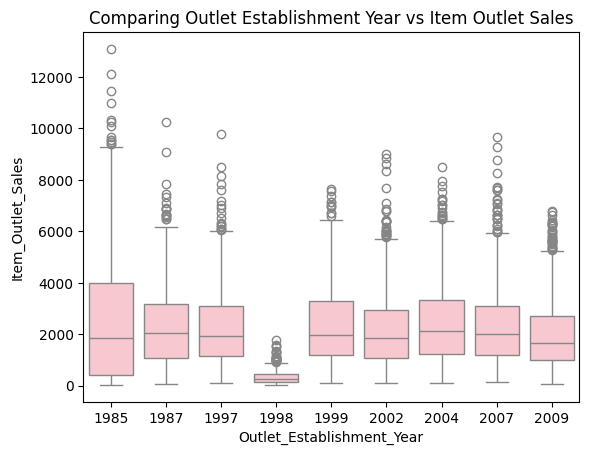

In [23]:
# make a Boxplot for Comparing Outlet Establishment Year vs Item Outlet Sales
ax=sns.boxplot(data=new_df, y='Item_Outlet_Sales', x='Outlet_Establishment_Year',color='Pink')
ax.set_title('Comparing Outlet Establishment Year vs Item Outlet Sales');

## Count Plot

In [24]:
# Using select_dtypes to get categorical columns
cat_cols=df.select_dtypes(include='object').columns
cat_cols

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [25]:
# check how many categories in each column of cat_cols
for col in cat_cols:
  print(col)
  print(df[col].value_counts())

Item_Identifier
Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
Item_Fat_Content
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64
Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
Outlet_Identifier
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Na

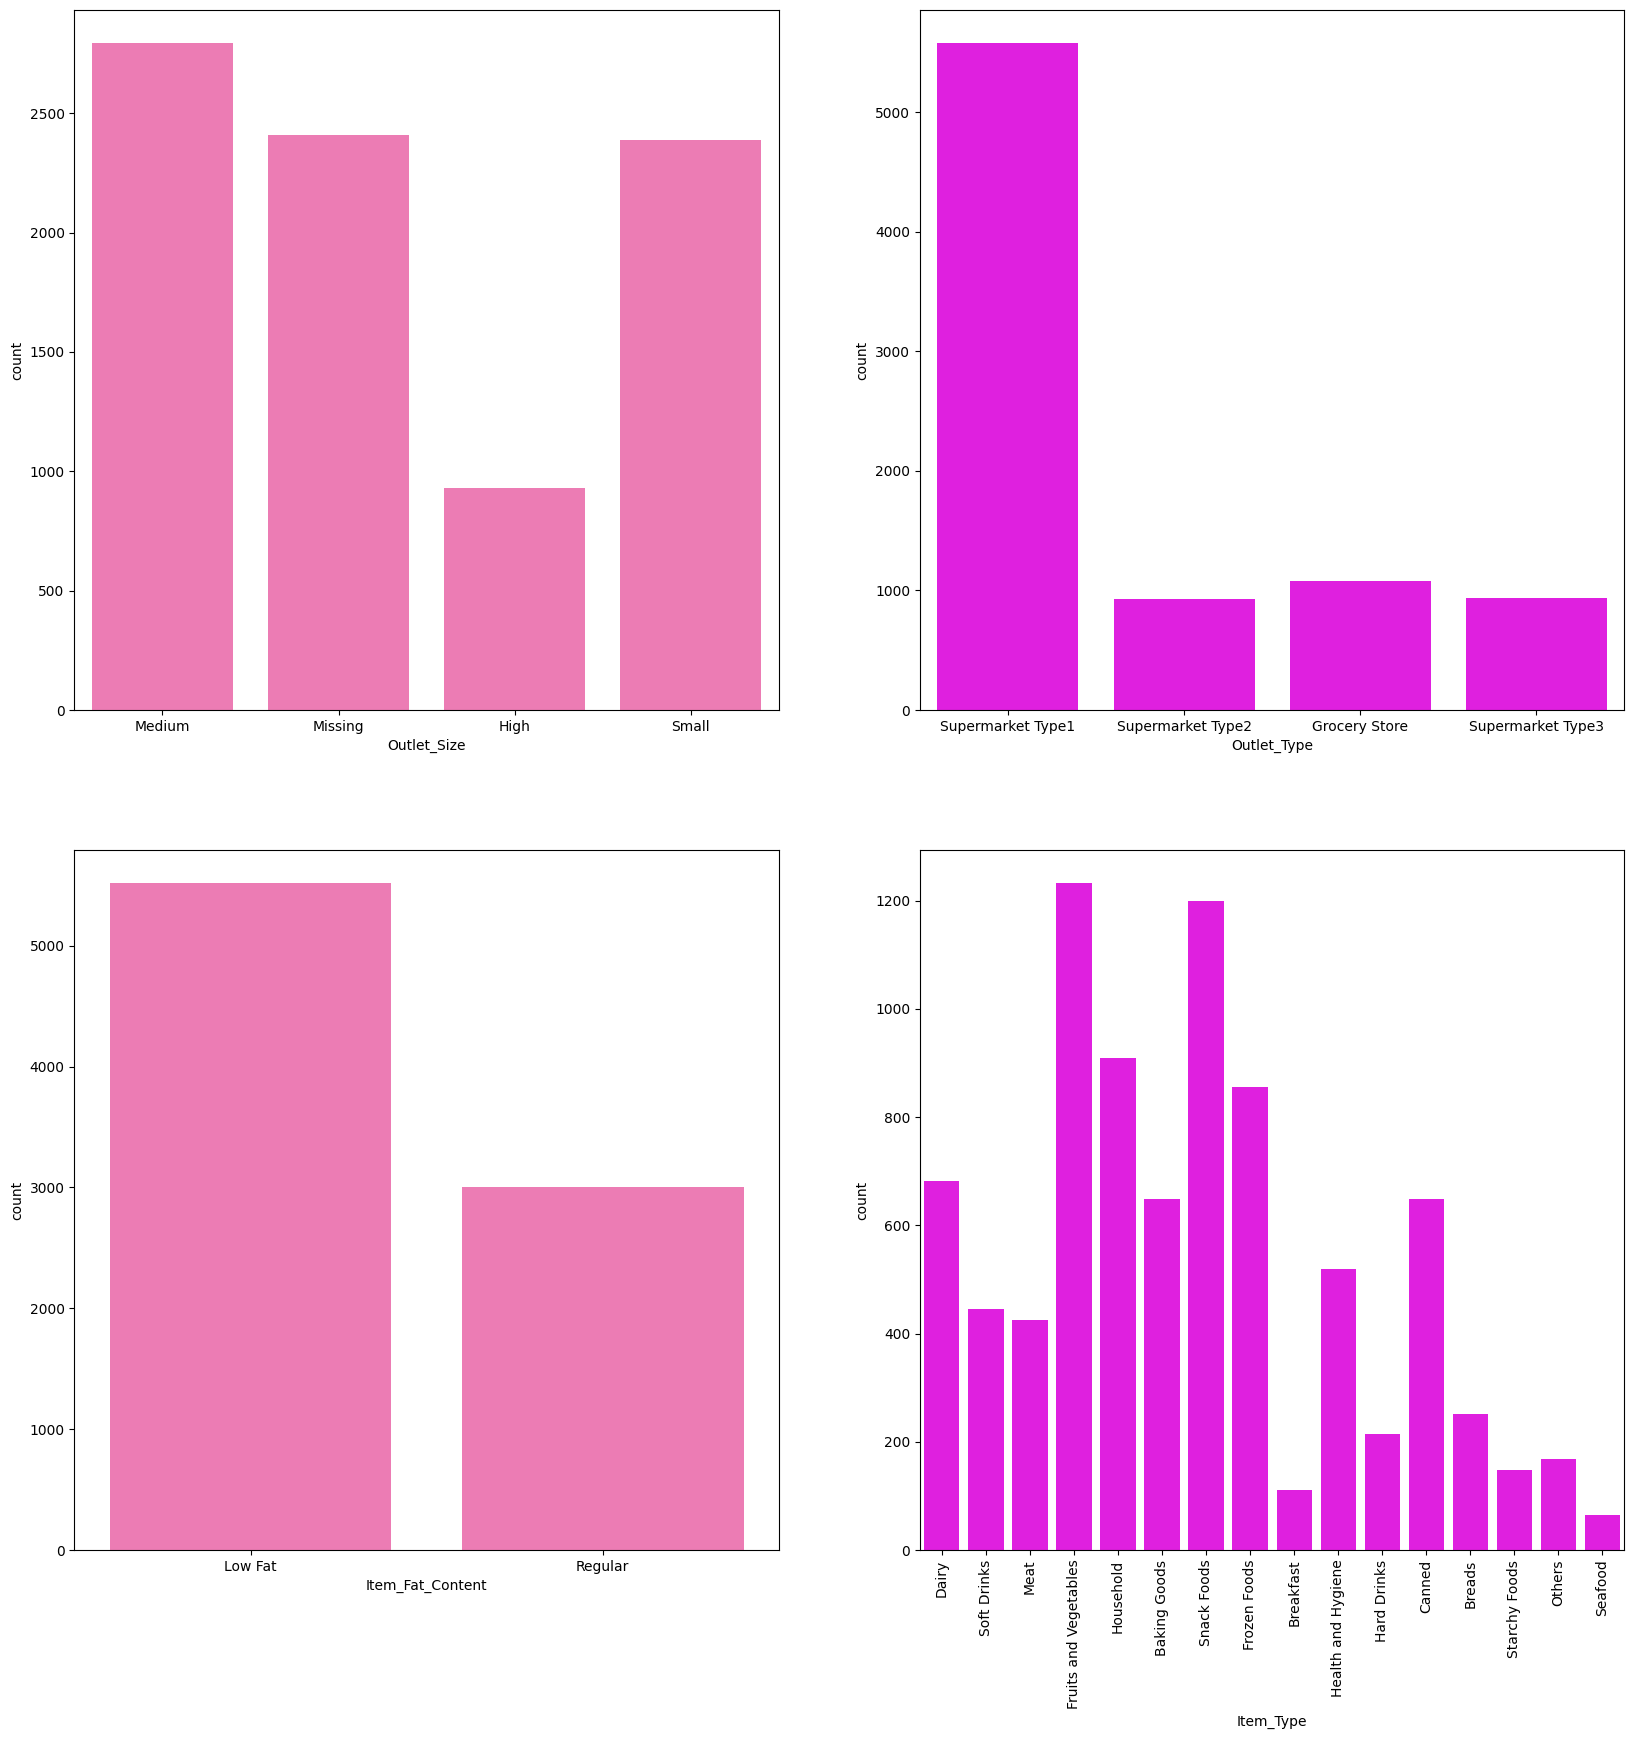

In [26]:
# make a count plots for the categorical columns
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(20,20))
ax[0][0]=sns.countplot(x='Outlet_Size',data=new_df,ax=ax[0][0],color='#FF69B4')
ax[0][0].set_title='count of Outlet Size'

ax[0][1]=sns.countplot(x='Outlet_Type',data=new_df,ax=ax[0][1],color='#FF00FF')
ax[0][1].set_title='count of Outlet Type'

ax[1][0]=sns.countplot(x='Item_Fat_Content',data=new_df,ax=ax[1][0],color='#FF69B4')
ax[1][0].set_title='count of Item Fat Content'

ax[1][1]=sns.countplot(x='Item_Type',data=new_df,ax=ax[1][1],color='#FF00FF')
ax[1][1].set_title='count of Item Type'
ax[1][1].set_xticklabels(ax[1][1].get_xticklabels(),rotation=90);

## Heat Map Plot

<Axes: >

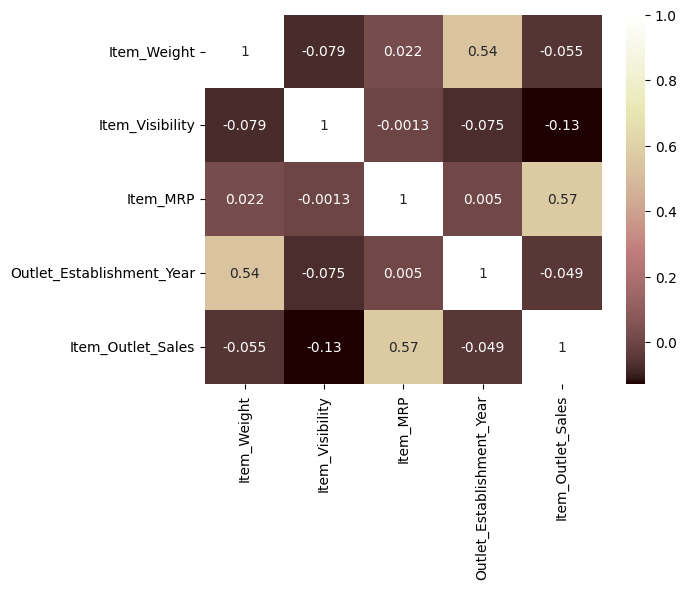

In [27]:
# make heatmap for correlation
crr=df.corr(numeric_only=True)
sns.heatmap(crr,annot=True,cmap="pink")

#Future Inspection

**The Target : Item_Outlet_Sales**

In [28]:
new_df['Item_Outlet_Sales'].dtype

dtype('float64')

## EDA Functions

In [29]:
"""UNIVARIATE PLOTTING FUNCTIONS FOR EDA"""
# Add the print statements to the function
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


# TO DO: add the new print statements from explore_categorical
def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes


In [30]:
"""MULTIVARIATE PLOTTING FUNCTIONS VS. NUMERIC TARGET"""

def plot_categorical_vs_target(df, x, y='item_Outlet_sales',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax


def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales',
                           figsize=(6,4),
                           ):
  """Plots a seaborn regplot with Pearson's correlation (r) added
  to the title.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # Make sure the plot is shown before the print statement
  plt.show()

  return fig, ax

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_categorical_vs_target2(df, x, y, figsize=(6,4), fillna = True, placeholder = "MISSING", order = None):
    # Make a copy of the dataframe and fillna
    temp_df = df.copy()
    # fillna with placeholder if fillna == True:
    if fillna == True:
        temp_df[x] = temp_df[x].fillna(placeholder)
    # or drop nulls prevent unwanted nan group in stripplot
    else:
        temp_df = temp_df.dropna(subset=[x])

    # Create the figure and subplots
    fig, ax = plt.subplots(figsize=figsize)

    # --- CHANGED LINE ---
    # Added estimator=sum to calculate total instead of mean
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidth=1, edgecolor='black', errorbar=None, estimator=sum)
    # --------------------

    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax, order=order,
                  hue_order=order, legend=False, edgecolor='white',
                  linewidth=0.5, size=3, zorder=0)

    # Rotate xlabels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Add a title
    ax.set_title(f"{x} vs. {y} (Sum)", fontweight='bold')
    fig.tight_layout()
    return fig, ax


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_categorical_vs_target_count(df, x, y, figsize=(6,4), fillna = True, placeholder = "MISSING", order = None):
    # Make a copy of the dataframe and fillna
    temp_df = df.copy()
    # fillna with placeholder if fillna == True:
    if fillna == True:
        temp_df[x] = temp_df[x].fillna(placeholder)
    # or drop nulls prevent unwanted nan group in stripplot
    else:
        temp_df = temp_df.dropna(subset=[x])

    # Create the figure and subplots
    fig, ax = plt.subplots(figsize=figsize)

    # --- CHANGED LINE ---
    # Added estimator=sum to calculate total instead of mean
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidth=1, edgecolor='black', errorbar=None, estimator='count')
    # --------------------

    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax, order=order,
                  hue_order=order, legend=False, edgecolor='white',
                  linewidth=0.5, size=3, zorder=0)

    # Rotate xlabels
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Add a title
    ax.set_title(f"{x} vs. {y} (count)", fontweight='bold')
    fig.tight_layout()
    return fig, ax


## replace the placeholder with Nan

In [33]:
new_df['Item_Weight']=new_df['Item_Weight'].replace(-1,np.nan)
new_df['Outlet_Size']=new_df['Outlet_Size'].replace('Missing',np.nan)
new_df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


## Feature 1 : {Item_Weight}

- Item _Weight : Weight of product

In [34]:
# Confirming the dtype to select correct EDA function
feature='Item_Weight'
new_df[feature].dtype

dtype('float64')

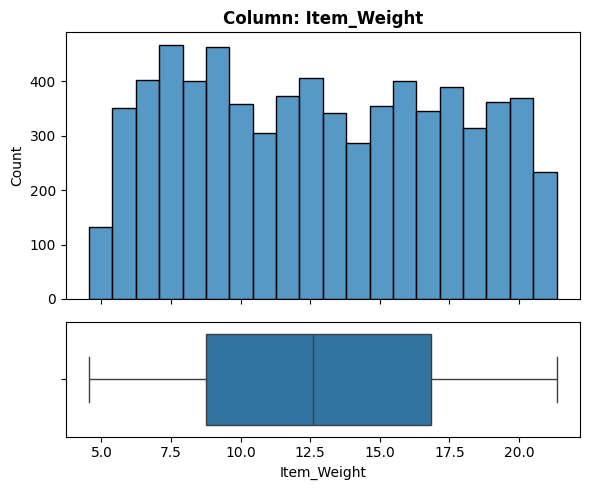

- NaN's Found: 1463 (17.17%)
- Unique Values: 415
- Most common value: 'nan' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [35]:
# run the appropriate explore function (based on feature's dtype)
explore_numeric(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 1463 (17.17%)
  - Impute with Median.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 416 unique values (high)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No , It may effects on the target.



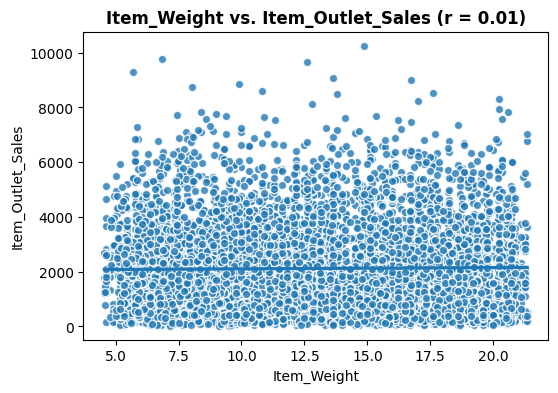

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Weight vs. Item_Outlet_Sales (r = 0.01)'}, xlabel='Item_Weight', ylabel='Item_Outlet_Sales'>)

In [36]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(new_df,feature ,'Item_Outlet_Sales')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes.
  - Does this feature appear to be a predictor of the target?
    - No.

___

## Feature 2 : {Item_Fat_Content}

- Item_Fat_Content : Whether the product is low_fat or regular

In [37]:
# Confirming the dtype to select correct EDA function
feature='Item_Fat_Content'
new_df[feature].dtype

dtype('O')

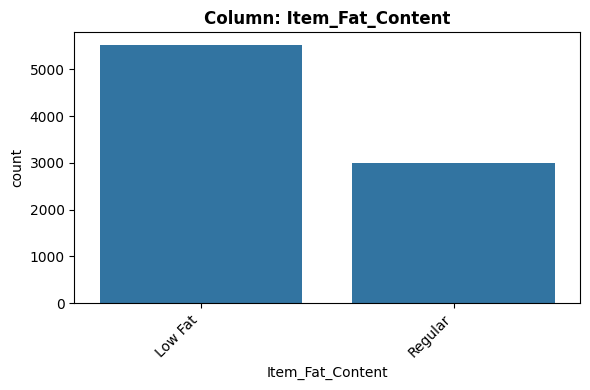

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [38]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 2 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

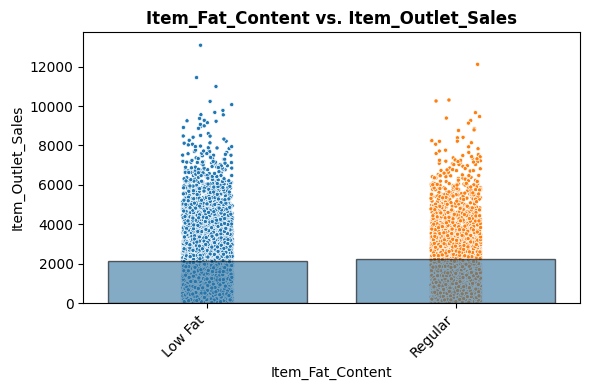

In [39]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , )

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Fat_Content vs. Item_Outlet_Sales (Sum)'}, xlabel='Item_Fat_Content', ylabel='Item_Outlet_Sales'>)

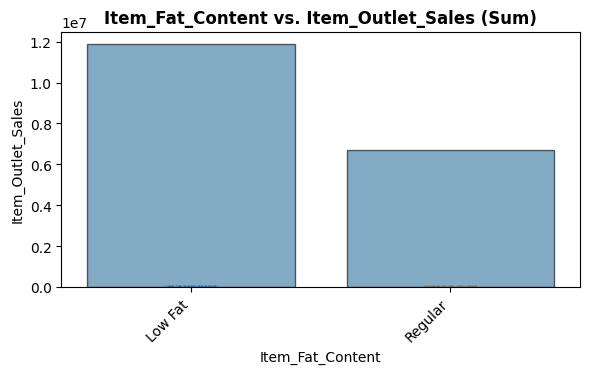

In [40]:
plot_categorical_vs_target2(new_df,feature ,'Item_Outlet_Sales' , )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No.
  - Does this feature appear to be a predictor of the target?
    - No.

___

## Feature 3 : {Item_Type}

- Item_Type :  The category to which the product belongs

In [41]:
# Confirming the dtype to select correct EDA function
feature='Item_Type'
new_df[feature].dtype

dtype('O')

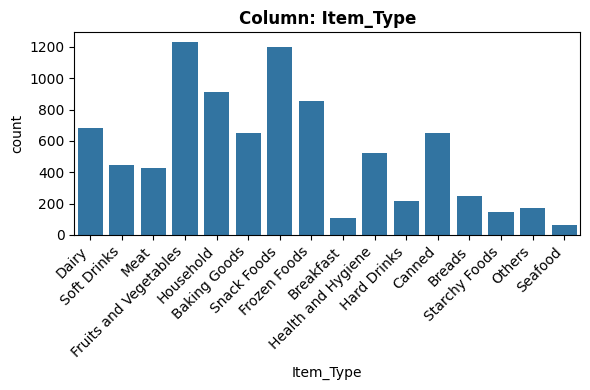

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [42]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 16 unique values (high)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Type vs. Item_Outlet_Sales'}, xlabel='Item_Type', ylabel='Item_Outlet_Sales'>)

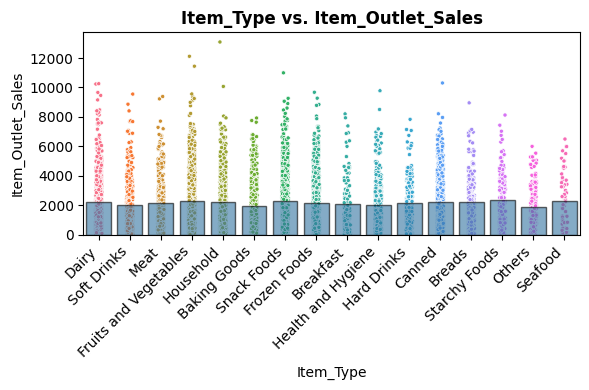

In [43]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , )

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Type vs. Item_Outlet_Sales (Sum)'}, xlabel='Item_Type', ylabel='Item_Outlet_Sales'>)

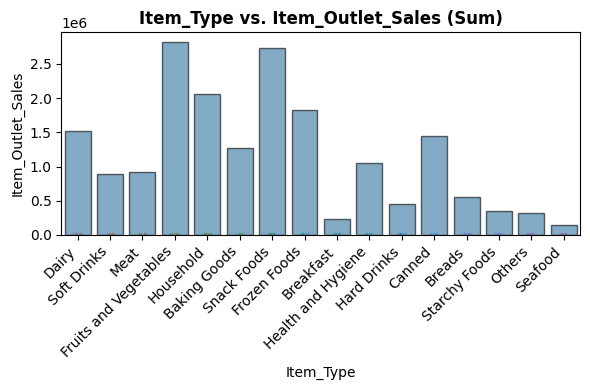

In [44]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target2(new_df,feature ,'Item_Outlet_Sales' , )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - yes
  - Does this feature appear to be a predictor of the target?
    - no

___

## Feature 4 : {Item_Visibility}

- Item_Visibility : the percentage of total display area of all products in a store allocated to the particular product

In [45]:
# Confirming the dtype to select correct EDA function
feature='Item_Visibility'
new_df[feature].dtype

dtype('float64')

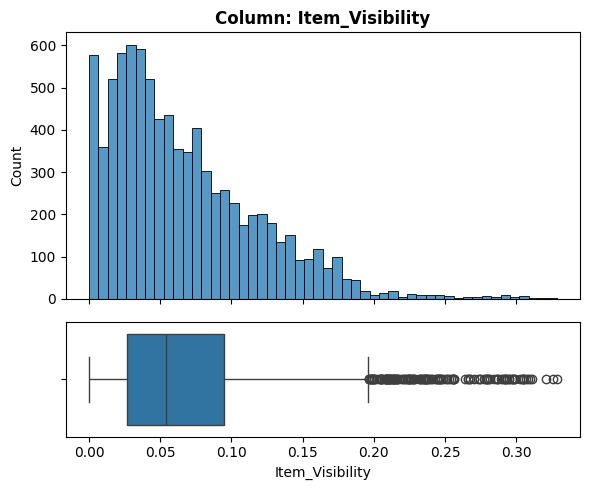

- NaN's Found: 0 (0.0%)
- Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


In [46]:
# run the appropriate explore function (based on feature's dtype)
explore_numeric(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 7880 unique values (high)

5. Would we know this BEFORE the target is determined?
  - no .

6. Is there a business case/understanding reason to exclude based on our business case?
  - No , It may effects on the target.



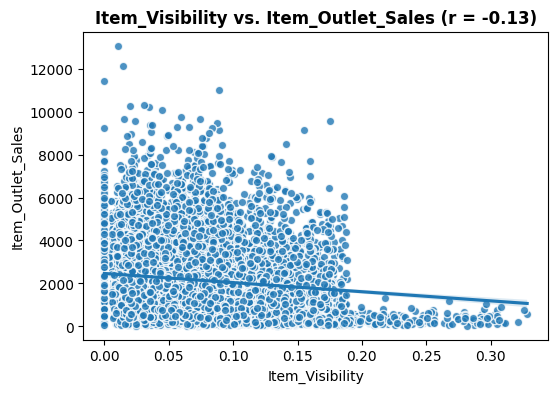

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_Visibility vs. Item_Outlet_Sales (r = -0.13)'}, xlabel='Item_Visibility', ylabel='Item_Outlet_Sales'>)

In [47]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(new_df,feature ,'Item_Outlet_Sales')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No
  - Does this feature appear to be a predictor of the target?
    - yes

___

## Feature 5 : {Item_MRP}

- Item_MRP : Maximum retail price (list price) of the product

In [48]:
# Confirming the dtype to select correct EDA function
feature='Item_MRP'
new_df[feature].dtype

dtype('float64')

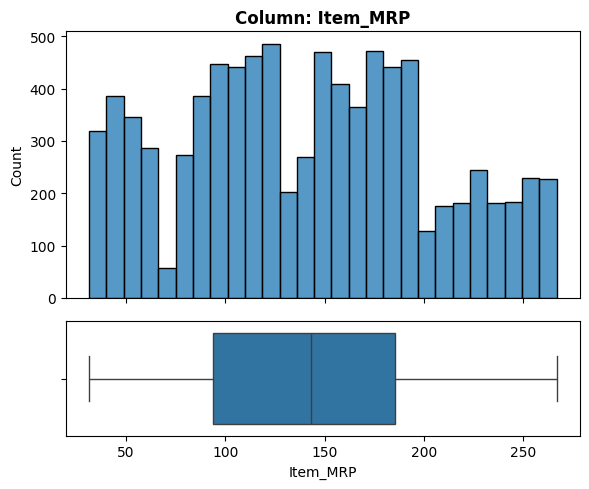

- NaN's Found: 0 (0.0%)
- Unique Values: 5938
- Most common value: '172.0422' occurs 7 times (0.08%)
- Not constant or quasi-constant.


In [49]:
# run the appropriate explore function (based on feature's dtype)
explore_numeric(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 5938 unique values (high)

5. Would we know this BEFORE the target is determined?
  - yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No , It may effects on the target.



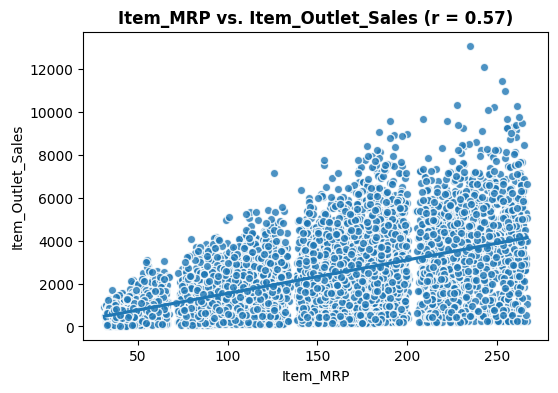

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Item_MRP vs. Item_Outlet_Sales (r = 0.57)'}, xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>)

In [50]:
# Run the appropriate feature vs. target function (based on dtype)
plot_numeric_vs_target(new_df,feature ,'Item_Outlet_Sales')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No
  - Does this feature appear to be a predictor of the target?
    - yes

___

## Feature 6 : {Outlet_Size}

- Outlet_Size: the size of the store in terms of ground area covered

In [51]:
# Confirming the dtype to select correct EDA function
feature='Outlet_Size'
new_df[feature].dtype

dtype('O')

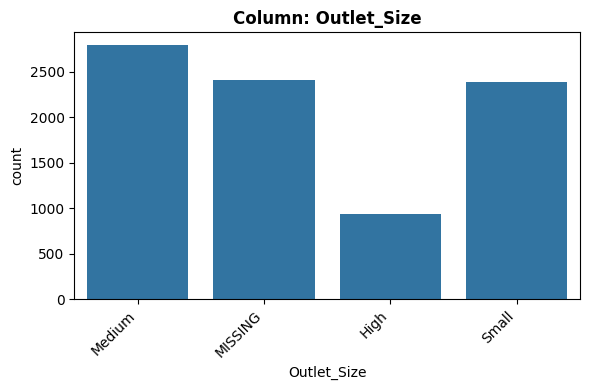

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [52]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 2410 (28.28%)
  - Impute with the Mode

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 4 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Size vs. Item_Outlet_Sales'}, xlabel='Outlet_Size', ylabel='Item_Outlet_Sales'>)

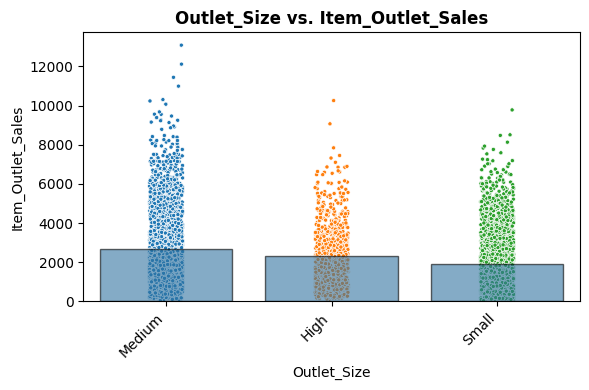

In [53]:
# Run the appropriate feature vs. target function (based on dtype)
# replace the missing values with the mode using mode()
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , placeholder=new_df[feature].mode())

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Size vs. Item_Outlet_Sales (Sum)'}, xlabel='Outlet_Size', ylabel='Item_Outlet_Sales'>)

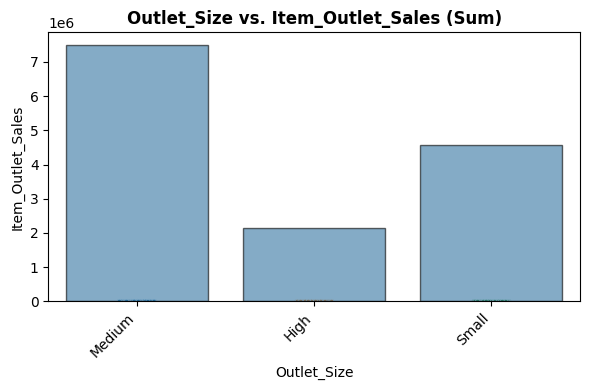

In [54]:
plot_categorical_vs_target2(new_df,feature ,'Item_Outlet_Sales' , placeholder=new_df[feature].mode() )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - yes
  - Does this feature appear to be a predictor of the target?
    - yes

___

## Feature 7 : {Outlet_Establishment_Year}

- Outlet_Establishment_Year : the year in which store was established

In [55]:
# Confirming the dtype to select correct EDA function
feature='Outlet_Establishment_Year'
new_df[feature].dtype

dtype('int64')

In [56]:
# change feature data type to object
new_df[feature]=new_df[feature].astype('object')

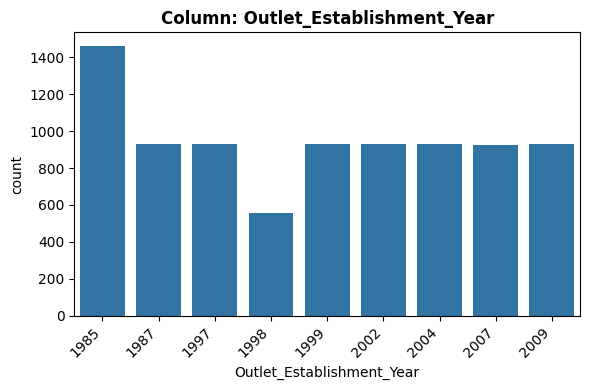

- NaN's Found: 0 (0.0%)
- Unique Values: 9
- Most common value: '1985' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [57]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 9 unique values (low)

5. Would we know this BEFORE the target is determined?
  - yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No , It may effects on the target.



(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Establishment_Year vs. Item_Outlet_Sales'}, xlabel='Outlet_Establishment_Year', ylabel='Item_Outlet_Sales'>)

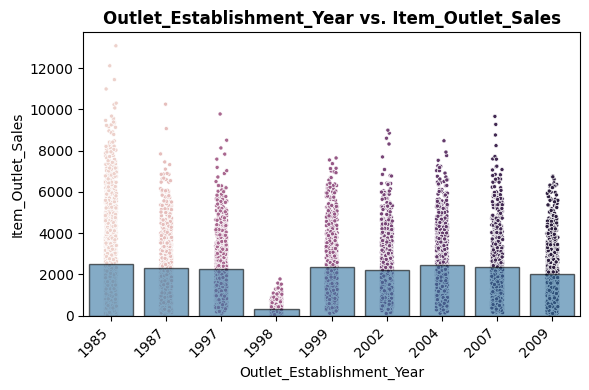

In [58]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales')

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - yes
  - Does this feature appear to be a predictor of the target?
    - yes

___

## Feature 8 : {Outlet_Location_Type}

- Outlet_Location_Type: the type of area in which the store is located

In [59]:
# Confirming the dtype to select correct EDA function
feature='Outlet_Location_Type'
new_df[feature].dtype

dtype('O')

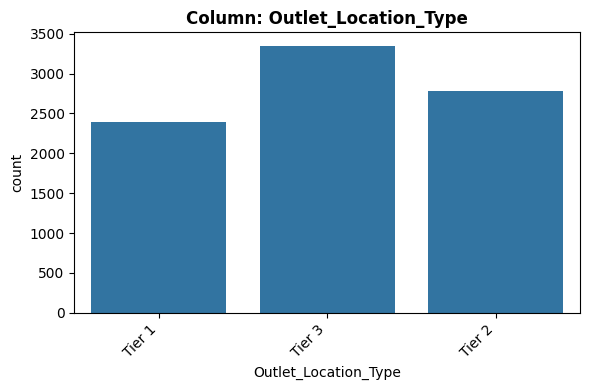

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [60]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 3 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Location_Type vs. Item_Outlet_Sales'}, xlabel='Outlet_Location_Type', ylabel='Item_Outlet_Sales'>)

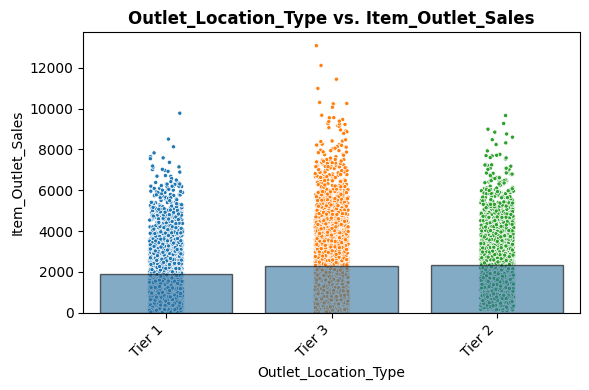

In [61]:
# Run the appropriate feature vs. target function (based on dtype)
# replace the missing values with the mode using mode()
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , placeholder=new_df[feature].mode())

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Location_Type vs. Item_Outlet_Sales (Sum)'}, xlabel='Outlet_Location_Type', ylabel='Item_Outlet_Sales'>)

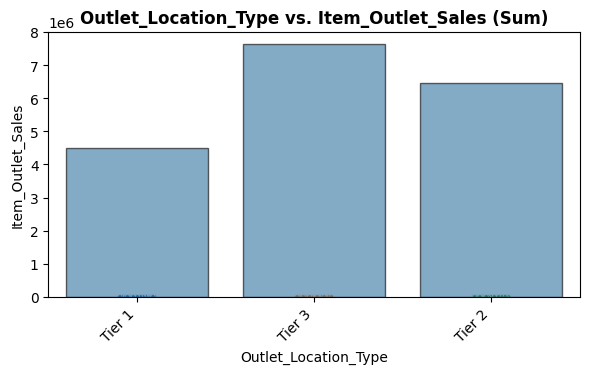

In [62]:
plot_categorical_vs_target2(new_df,feature ,'Item_Outlet_Sales'  )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - yes
  - Does this feature appear to be a predictor of the target?
    - yes

___

## Feature 9 : {Outlet_Type}

- Outlet_Type: whether the outlet is a grocery store or some sort of supermarket

In [63]:
# Confirming the dtype to select correct EDA function
feature='Outlet_Type'
new_df[feature].dtype

dtype('O')

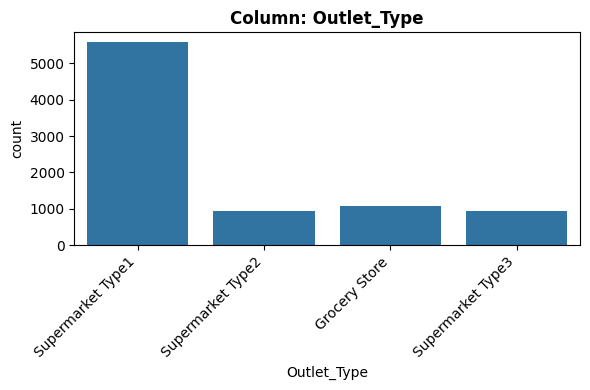

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [64]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 4 unique values (low)

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Type vs. Item_Outlet_Sales'}, xlabel='Outlet_Type', ylabel='Item_Outlet_Sales'>)

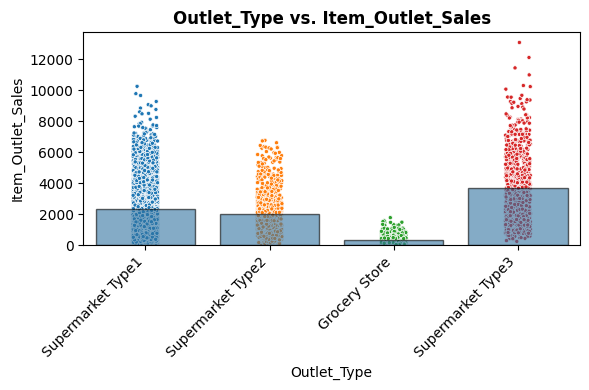

In [65]:
# Run the appropriate feature vs. target function (based on dtype)
# replace the missing values with the mode using mode()
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales' , placeholder=new_df[feature].mode())

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Type vs. Item_Outlet_Sales (Sum)'}, xlabel='Outlet_Type', ylabel='Item_Outlet_Sales'>)

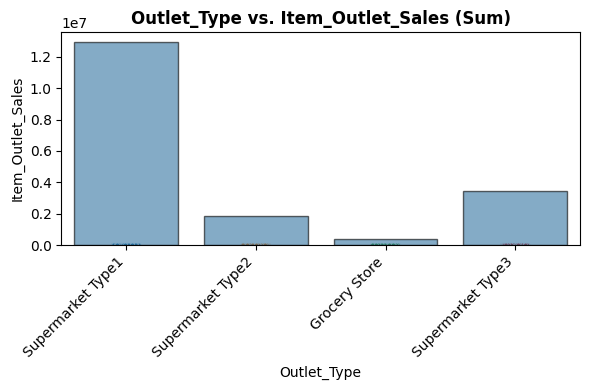

In [66]:
plot_categorical_vs_target2(new_df,feature ,'Item_Outlet_Sales'  )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - yes
  - Does this feature appear to be a predictor of the target?
    - yes

___

## Feature 10 : {Outlet_Identifier}

- Outlet_Identifier: Store ID

In [67]:
# Confirming the dtype to select correct EDA function
feature='Outlet_Identifier'
new_df[feature].dtype

dtype('O')

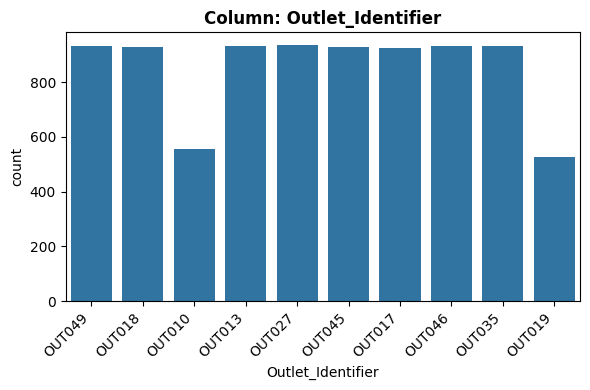

- NaN's Found: 0 (0.0%)
- Unique Values: 10
- Most common value: 'OUT027' occurs 935 times (10.97%)
- Not constant or quasi-constant.


In [68]:
# run the appropriate explore function (based on feature's dtype)
explore_categorical(new_df,feature);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - 10 unique values (low )

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  -No



(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Identifier vs. Item_Outlet_Sales'}, xlabel='Outlet_Identifier', ylabel='Item_Outlet_Sales'>)

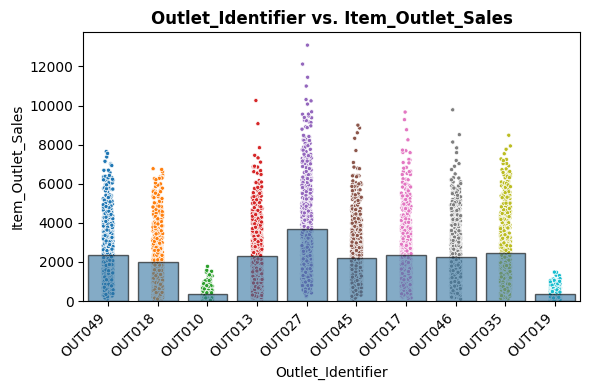

In [69]:
# Run the appropriate feature vs. target function (based on dtype)
plot_categorical_vs_target(new_df,feature ,'Item_Outlet_Sales'  )

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Outlet_Identifier vs. Item_Outlet_Sales (Sum)'}, xlabel='Outlet_Identifier', ylabel='Item_Outlet_Sales'>)

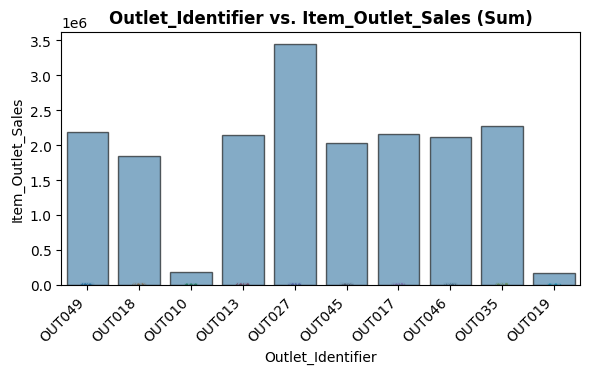

In [70]:
plot_categorical_vs_target2(new_df,feature ,'Item_Outlet_Sales'  )

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No
  - Does this feature appear to be a predictor of the target?
    - yes

___

## Conclusion for the EDA

- In conclusion, the most influential predictors of product sales emerged as Item_MRP, Outlet_Size, Outlet_Establishment_Year, Outlet_Type, Outlet_Location_Type, Outlet_Identifier, and Item_Visibility. These features consistently demonstrated strong correlations and contributions across model evaluations, underscoring their critical role in driving sales performance.


# Preprocesing for Machine Learning

In [71]:
## Typical Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Modeling & preprocessing import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer,make_column_transformer,make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler


In [72]:
from sklearn import set_config
set_config(transform_output='pandas')

In [73]:
df2=pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week05/Data/sales_predictions_2023.csv")
df2.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [74]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [75]:
# Checking for Duplicates
df2.duplicated().sum()

np.int64(0)

In [76]:
# Checking missing values
df2.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


## define the target and features

In [77]:
# determine the target and features
y=df2['Item_Outlet_Sales']
X=df2.drop(columns=['Item_Identifier','Item_Outlet_Sales'])

In [78]:
# checking inconsistent categories
for x in X:
  X[x].value_counts()
  print(X[x].value_counts())


Item_Weight
12.150    86
17.600    82
13.650    77
11.800    76
15.100    68
          ..
8.920      2
6.520      1
9.420      1
7.685      1
5.400      1
Name: count, Length: 415, dtype: int64
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
Item_Visibility
0.000000    526
0.076975      3
0.061271      2
0.046825      2
0.112399      2
           ... 
0.054142      1
0.018920      1
0.044974      1
0.103611      1
0.083060      1
Name: count, Length: 7880, dtype: int64
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast            

In [79]:
# replace the inconstancy values with the right values
df2['Item_Fat_Content']= df2['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

## train_test_split

In [80]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=1)

## Display the number of null values in x_train

In [81]:
X_train.isnull().sum()

,0
Item_Weight,1091
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1791
Outlet_Location_Type,0
Outlet_Type,0


## Display the number of null values in x_train

In [82]:
X_test.isnull().sum()

,0
Item_Weight,372
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,619
Outlet_Location_Type,0
Outlet_Type,0


## Column Transformer

In [83]:
# PREPROCESSING PIPELINE FOR NUMERIC DATA

# Save list of column names

num_cols = X_train.select_dtypes("number").columns

print("Numeric Columns:", num_cols)

# instantiate preprocessors

impute_median = SimpleImputer(strategy='median')

scaler = StandardScaler()

# Make a numeric preprocessing pipeline

num_pipe = make_pipeline(impute_median, scaler)

num_pipe

Numeric Columns: Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')


Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [84]:
num_tuple=('numeric',num_pipe,num_cols)
num_tuple

('numeric',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
        'Outlet_Establishment_Year'],
       dtype='object'))

In [85]:
# PREPROCESSING PIPELINE FOR ORDINAL DATA
# make a pipeline

#Save list of column names
# Prepare ordinal pipeline
ord_cols = ['Outlet_Size']

print("ordinal Columns:", ord_cols)
# Create imputer for ordinal data
impute_common = SimpleImputer(strategy='most_frequent')

## Making the OrdinalEncoder

#  Ordinal Encoder
Outlet_Size_order = ['Small','Medium','High']


# Making the list of order lists for OrdinalEncoder
ord_encoder = OrdinalEncoder(categories=[Outlet_Size_order])


# Making a final scaler to scale category #'s

scaler = StandardScaler()

## Making an ord_pipe

ord_pipe = make_pipeline(impute_common, ord_encoder, scaler)
ord_pipe

ordinal Columns: ['Outlet_Size']


Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('ordinalencoder',
                 OrdinalEncoder(categories=[['Small', 'Medium', 'High']])),
                ('standardscaler', StandardScaler())])

In [86]:
ord_tuple=('ordinal',ord_pipe,ord_cols)
ord_tuple

('ordinal',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('ordinalencoder',
                  OrdinalEncoder(categories=[['Small', 'Medium', 'High']])),
                 ('standardscaler', StandardScaler())]),
 ['Outlet_Size'])

In [87]:
# PREPROCESSING PIPELINE FOR ONE-HOT-ENCODED DATA

# Save list of column names

ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns

print("OneHotEncoder Columns:", ohe_cols)

# Instantiate the individual preprocessors

impute_na = SimpleImputer(strategy='constant', fill_value = "NA")

ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Make pipeline with imputer and encoder

ohe_pipe = make_pipeline(impute_na, ohe_encoder)

ohe_pipe

OneHotEncoder Columns: Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')


Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='NA', strategy='constant')),
                ('onehotencoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [88]:
cat_tuple=('categorical',ohe_pipe,ohe_cols)
cat_tuple

('categorical',
 Pipeline(steps=[('simpleimputer',
                  SimpleImputer(fill_value='NA', strategy='constant')),
                 ('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
        'Outlet_Location_Type', 'Outlet_Type'],
       dtype='object'))

In [89]:
col_transformer=ColumnTransformer(
    [
        num_tuple,
        ord_tuple,
        cat_tuple],
    verbose_feature_names_out=False)

# Fit on Training Data

In [90]:
col_transformer.fit(X_train)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                ('ordinal',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinalencoder',
                                                  Ord...
                                                  StandardScaler())]),
                                 ['Outlet_Size']),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))],
                  verbose_feature_names_out=False)

# transforming on training and testing data

In [91]:
x_train_transformed=col_transformer.transform(X_train)
x_test_transformed=col_transformer.transform(X_test)

# Building the Models

In [92]:
len(y_train)

6392

In [93]:
x_train_transformed.shape[0]

6392

In [94]:
# import libraries
import pandas as pd                     # for loading and working with data tables
import matplotlib.pyplot as plt        # for plotting graphs

from sklearn.model_selection import train_test_split   # to split data into training and testing sets
from sklearn.preprocessing import StandardScaler       # to scale features
from sklearn.linear_model import LinearRegression      # linear regression model
from sklearn.tree import DecisionTreeRegressor         # decision tree regression model
from sklearn.ensemble import RandomForestRegressor     # random forest regression model
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# functions to evaluate the model

## linear Regression

In [109]:
# Train the model
model = LinearRegression()
# create a linear regression model

model.fit(x_train_transformed, y_train)
# train the model using training data (learn weights and bias)

LinearRegression()

### Evaluate the model for Training set

In [96]:
y_train_pred = model.predict(x_train_transformed)

In [97]:
# Evaluate the model

mae = mean_absolute_error(y_train,y_train_pred)
# average difference between real and predicted values

rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_train,y_train_pred)
# how well the model fits the data (closer to 1 is better)

# print results
print('LinearRegression for training data')
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

LinearRegression for training data
MAE  = 833.65
RMSE = 1128.049
R^2  = 0.564


### Evaluate the model for the testing set

In [98]:
y_pred_test = model.predict(x_test_transformed)

In [99]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred_test)
# average difference between real and predicted values

rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_test, y_pred_test)
# how well the model fits the data (closer to 1 is better)

# print results
print('LinearRegression for testing data')
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

LinearRegression for testing data
MAE  = 839.19
RMSE = 1126.282
R^2  = 0.562


**There is no overfit neither underfit , the results is closer to each other and the model is performing well**

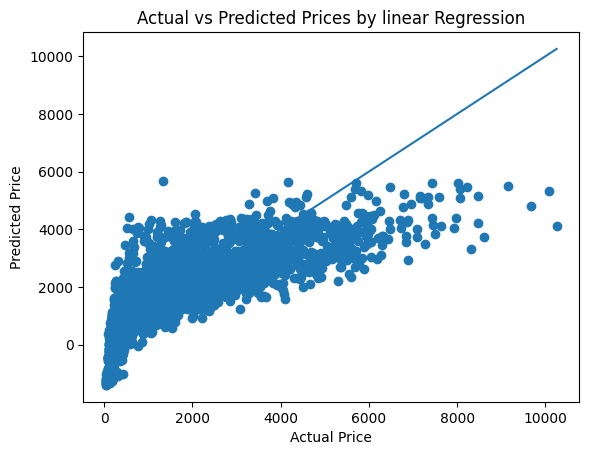

In [100]:
# Visualize model with real data

plt.scatter(y_test, y_pred_test)
# plot actual values vs predicted values (each point = one house)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
# draw diagonal line (perfect prediction line)

plt.title("Actual vs Predicted Prices by linear Regression")
# title of the graph

plt.xlabel("Actual Price")
# x-axis: real prices

plt.ylabel("Predicted Price")
# y-axis: predicted prices

plt.show()
# display the graph

### model insight

In [111]:
feature_names = col_transformer.get_feature_names_out()



In [114]:
X_train_tf = pd.DataFrame(col_transformer.transform(X_train),
                          columns = feature_names, index = X_train.index)

X_test_tf = pd.DataFrame(col_transformer.transform(X_test),
                          columns = feature_names, index = X_test.index)
X_test_tf.head(3)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,...,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
1070,0.154483,-0.217848,-1.683729,0.499522,0.271576,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
6305,-0.081353,0.151844,-0.864153,1.333811,0.271576,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8504,-0.045978,1.129583,-0.479866,-1.526609,0.271576,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [115]:
coeffs = pd.Series(model.coef_, index=feature_names,
                        name='Coefficients')
coeffs.loc['intercept'] = model.intercept_
coeffs.head()

,Coefficients
Item_Weight,7.885785
Item_Visibility,-20.311032
Item_MRP,971.233184
Outlet_Establishment_Year,-78.339073
Outlet_Size,24.136038


In [118]:
top_n=3
coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
top_n_features = coeff_rank.head(top_n)
coeffs_plot = coeffs.loc[top_n_features.index].sort_values()
coeffs_plot

,Coefficients
Outlet_Type_Grocery Store,-1091.187430
Item_MRP,971.233184
intercept,1984.358700


In [121]:
def plot_coeffs(coeffs, top_n=None,  figsize=(4,5), intercept=False,
                annotate=False, ha='left',va='center', size=12, xytext=(4,0),
                  textcoords='offset points'):
    """Plots the top_n coefficients from a Series, with optional annotations."""
    if (intercept==False) & ('intercept' in coeffs.index):
        coeffs = coeffs.drop('intercept')
    if top_n==None:
        ## sort all features and set title
        plot_vals = coeffs#.sort_values()
        title = "All Coefficients - Ranked by Magnitude"
    else:
        ## rank the coeffs and select the top_n
        coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
        top_n_features = coeff_rank.head(top_n)
        plot_vals = coeffs.loc[top_n_features.index].sort_values()
        ## sort features and keep top_n and set title
        title = f"Top {top_n} Largest Coefficients"
    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Coefficient',
           ylabel='Feature Names',
           title=title)
    ax.axvline(0, color='k')

    if annotate==True:
        annotate_hbars(ax, ha=ha,va=va,size=size,xytext=xytext,
                       textcoords=textcoords)
    ## return ax in case want to continue to update/modify figure
    return ax

def annotate_hbars(ax, ha='left',va='center',size=12,  xytext=(4,0),
                  textcoords='offset points'):
    for bar in ax.patches:

        ## calculate center of bar
        bar_ax = bar.get_y() + bar.get_height()/2
        ## get the value to annotate
        val = bar.get_width()
        if val < 0:
            val_pos = 0
        else:
            val_pos = val
        # ha and va stand for the horizontal and vertical alignment
        ax.annotate(f"{val:.3f}", (val_pos,bar_ax), ha=ha,va=va,size=size,
                        xytext=xytext, textcoords=textcoords)

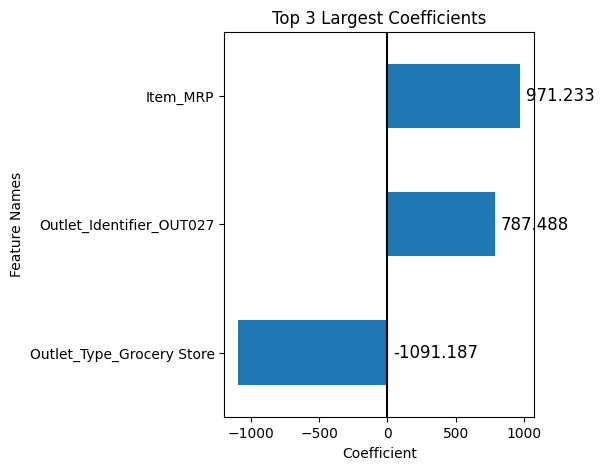

In [122]:
plot_coeffs(coeffs,top_n=3,intercept=False,annotate=True);

## Random Forest

In [101]:
# Train the model
model2 = RandomForestRegressor(random_state =42)
# create a RandomForestRegressor model

model2.fit(x_train_transformed, y_train)
# train the model using training data (learn weights and bias)

RandomForestRegressor(random_state=42)

### Evaluate the model for Training set

In [102]:
y_train_pred2= model2.predict(x_train_transformed)

In [103]:
# Evaluate the model

mae = mean_absolute_error(y_train,y_train_pred2)
# average difference between real and predicted values

rmse = mean_squared_error(y_train, y_train_pred2) ** 0.5
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_train,y_train_pred2)
# how well the model fits the data (closer to 1 is better)

# print results
print('RandomForestRegressor for training data')
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

RandomForestRegressor for training data
MAE  = 294.412
RMSE = 424.987
R^2  = 0.938


### Evaluate the model for the testing set

In [104]:
y_pred2 = model2.predict(x_test_transformed)

In [105]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred2)
# average difference between real and predicted values

rmse = mean_squared_error(y_test, y_pred2) ** 0.5
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_test, y_pred2)
# how well the model fits the data (closer to 1 is better)

# print results
print('RandomForestRegressor for testing data')
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

RandomForestRegressor for testing data
MAE  = 790.439
RMSE = 1136.838
R^2  = 0.554


**There is an overfitting the model is performing well on the training data but not on the testing data**

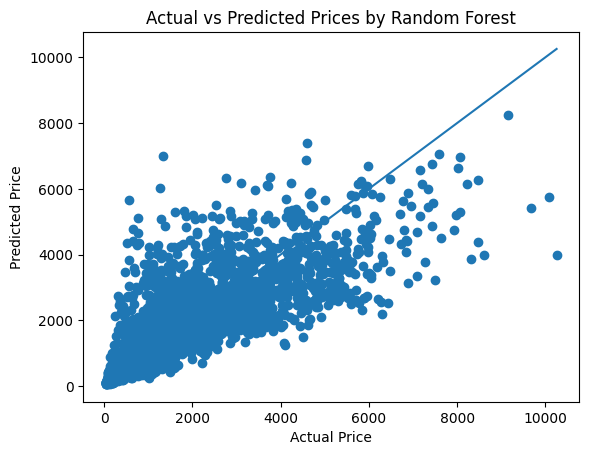

In [106]:
# Visualize model with real data

plt.scatter(y_test, y_pred2)
# plot actual values vs predicted values (each point = one house)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
# draw diagonal line (perfect prediction line)

plt.title("Actual vs Predicted Prices by Random Forest")
# title of the graph

plt.xlabel("Actual Price")
# x-axis: real prices

plt.ylabel("Predicted Price")
# y-axis: predicted prices

plt.show()
# display the graph

## Tuned random Forest

In [108]:
# Define param grid
param_grid = {
    'n_estimators': [50, 100, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 0.5]
}

# Fit the gridsearch on the training data (X and y matching)
gridsearch = GridSearchCV(model2, param_grid, n_jobs=-1, verbose=1, cv=5)
gridsearch.fit(x_train_transformed, y_train)
# Get best parameters
print(gridsearch.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'max_depth': 10, 'max_features': 0.5, 'min_samples_split': 5, 'n_estimators': 400}


#### Using GridsearchCV

In [ ]:
# Define a model with the best parameters already refit on the entire trainingset
tuned_rf = gridsearch.best_estimator_
tuned_rf.set_params(random_state=42)

In [ ]:
y_train_pred3= tuned_rf.predict(x_train_transformed)

In [ ]:
# Evaluate the model

mae = mean_absolute_error(y_train,y_train_pred3)
# average difference between real and predicted values

rmse = mean_squared_error(y_train, y_train_pred3) ** 0.5
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_train,y_train_pred3)
# how well the model fits the data (closer to 1 is better)

# print results
print(' Tuned RandomForestRegressor for training data')
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

### Evaluate the model for the testing set

In [ ]:
y_pred3 = tuned_rf.predict(x_test_transformed)

In [ ]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred3)
# average difference between real and predicted values

rmse = mean_squared_error(y_test, y_pred3) ** 0.5
# error with more penalty for large mistakes (square then root)

r2 = r2_score(y_test, y_pred3)
# how well the model fits the data (closer to 1 is better)

# print results
print('Tuned RandomForestRegressor for testing data')
print("MAE  =", round(mae, 3))   # average error
print("RMSE =", round(rmse, 3))  # weighted error
print("R^2  =", round(r2, 3))    # model performance

**There is a little overfitting but overall the model is performing well on both training and testing**

In [ ]:
# Visualize model with real data

plt.scatter(y_test, y_pred3)
# plot actual values vs predicted values (each point = one house)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
# draw diagonal line (perfect prediction line)

plt.title("Actual vs Predicted Prices by Tuned Random Forest")
# title of the graph

plt.xlabel("Actual Price")
# x-axis: real prices

plt.ylabel("Predicted Price")
# y-axis: predicted prices

plt.show()
# display the graph

# Evaluation

###  Recommended Model: Tuned Random Forest Regressor

After evaluating all three models, I recommend the **Tuned Random Forest Regressor** as the best model to move forward with.

---

### Justification

Looking at the results across all three models:

- **Linear Regression** had consistent training and test scores (R² ≈ 0.56), meaning it is neither overfitting nor underfitting — but it simply doesn't explain the data well enough, leaving nearly 44% of the variance unexplained.

- **Untuned Random Forest** performed exceptionally well on training data (R² = 0.938) but collapsed on test data (R² = 0.561), which is a clear sign of severe overfitting. It essentially memorized the training data and failed to generalize.

- **Tuned Random Forest** struck the best balance — it reduced the overfitting seen in the untuned version while achieving a better test R² (0.591) than both Linear Regression and the untuned Random Forest. The gap between training and test scores is much more reasonable, making it the most generalizable and reliable model of the three.

---

###  Model Performance for Non-Technical Stakeholders

**R-Squared (R²):**

Our recommended model — the Tuned Random Forest — has an R² of **0.591 on test data**. Think of R² as a score that tells us how well our model explains what drives the outcome we're predicting. A score of 0.591 means that our model can explain about **59% of the variation** in the target variable. In simple terms, if you imagine 100 different cases in our data, our model correctly accounts for the patterns behind roughly 59 of them. While there is still room for improvement, this is a meaningful result and gives us a solid foundation to build on.

---

**Selected Metric: MAE (Mean Absolute Error)**

I chose **MAE** to communicate the model's error to stakeholders because it is the most straightforward and intuitive metric — it simply tells us, on average, how far off our predictions are from the actual values, in the same units as what we're predicting.

Our Tuned Random Forest has a test MAE of **760.857**, meaning that on average, our model's predictions are off by about **760 units** from the real value. Unlike RMSE, MAE doesn't exaggerate the impact of large errors, which makes it easier to interpret and communicate honestly to a non-technical audience.

---

###  Overfitting / Underfitting Analysis

| Model | Train R² | Test R² | Gap | Assessment |
|---|---|---|---|---|
| Linear Regression | 0.564 | 0.562 | 0.002 | Underfit — too simple |
| Untuned Random Forest | 0.938 | 0.554 | 0.384 | Severely overfit |
| **Tuned Random Forest** | **0.698** | **0.591** | **0.107** | **Mild overfit — best balance** |

The Tuned Random Forest shows a training R² of 0.703 versus a test R² of 0.592, a gap of about **0.107**. This tells us the model is **slightly overfit** — it performs somewhat better on data it has seen than on new data — but this gap is significantly smaller than the untuned version's gap of 0.378. The tuning process (via GridSearchCV) successfully reined in the overfitting by constraining the model's complexity, making it much more trustworthy when applied to real-world, unseen data.